# Small Nemotron-CC-Math Pretraining Run

Single-GPU BF16 pretraining example using `nvidia/Nemotron-CC-Math-v1`, packed batches, and AdamW.

In [1]:
import math
import os
import time
from pathlib import Path
import numpy as np
from operator import itemgetter

import datasets
import torch
from transformers import AutoTokenizer
from torch.optim import AdamW
import torch.nn.functional as F
from gram_newton_schulz import Muon, POLAR_EXPRESS_COEFFICIENTS

from nanomoe.data.packed_dataset import PackedPretrainStreamGroup, cu_seqlens_to_packing_metadata
from nanomoe.model import MoEConfig, create_model
from nanomoe.train import unified_loss
from nanomoe.optimizer import build_optimizer_muon, build_optimizer_adamw

from nanomoe.monitors import (
    HiddenStateMonitorResult,
    NeighbourLayerHiddenStateStats,
    TokenHiddenStateLayerStats,
    hidden_state_cosine_similarities
)

%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt

/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
torch.set_float32_matmul_precision("high")

if not torch.cuda.is_available():
    raise RuntimeError("This notebook is configured for a CUDA GPU, such as one H100.")

device = torch.device("cuda")
dtype = torch.bfloat16

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

dataset_name = "nvidia/Nemotron-CC-Math-v1"
dataset_config = "4plus"
# Use gpt2 tokenizer
tokenizer_name = "gpt2"

seq_len = 65536
max_seq_len = 2048
batch_size = 1          # independent packed streams per optimizer micro-step
grad_accum = 1          # effective tokens/step ~= seq_len * batch_size * grad_accum
max_steps = 100
log_every = 5

lr = 1e-4
weight_decay = 0.1
max_grad_norm = 1.0

print(f"device={device}, dtype={dtype}, torch={torch.__version__}")

device=cuda, dtype=torch.bfloat16, torch=2.10.0+cu128


In [3]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
print(f"tokenizer_vocab={len(tokenizer):,}")

tokenizer_vocab=50,257


In [4]:
hf_dataset = datasets.load_dataset(dataset_name, dataset_config, split="train", streaming=True)

val_examples = 100
train_hf_dataset = hf_dataset.skip(val_examples)
val_hf_dataset = hf_dataset.take(val_examples)

train_dataset = PackedPretrainStreamGroup(
    hf_dataset=train_hf_dataset,
    tokenizer=tokenizer,
    num_streams=batch_size,
    total_shards=batch_size,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=4,
    seed=seed,
    add_special_tokens=False,
 )

val_dataset = PackedPretrainStreamGroup(
    hf_dataset=val_hf_dataset,
    tokenizer=tokenizer,
    num_streams=batch_size,
    total_shards=batch_size,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=4,
    seed=seed,
    add_special_tokens=False,
 )

dataset = train_dataset

In [5]:
def compute_pretrain_loss(batch, aux_loss_coef=0.0, return_router_logits=False):
    batch = batch.to(device, non_blocking=True)
    input_ids = batch.tokens.unsqueeze(0)
    position_ids = batch.position_ids.unsqueeze(0)
    doc_ids, seq_lens = cu_seqlens_to_packing_metadata(batch.cu_seqlens)

    outputs = model(
        input_ids=input_ids,
        position_ids=position_ids,
        packing_doc_ids=doc_ids,
        packing_seq_lens=seq_lens,
        use_cache=False,
        return_router_logits=return_router_logits,
    )

    if batch.labels is None:
        raise ValueError("Packed pretraining batches must include labels.")

    logits = outputs.logits[0]
    lm_loss = unified_loss(logits, batch.labels, batch.token_weights)
    aux_loss = outputs.aux_loss
    if not torch.is_tensor(aux_loss):
        aux_loss = torch.tensor(aux_loss, device=device, dtype=lm_loss.dtype)

    total_loss = lm_loss + aux_loss * aux_loss_coef
    token_count = int(batch.token_weights[:-1].abs().sum().item())
    metrics = {
        "loss": float(lm_loss.detach()),
        "aux_loss": float(aux_loss.detach()),
        "tokens": token_count,
    }

    if return_router_logits:
        router_expert_indices = outputs.router_expert_indices
        entropies = []
        for router_expert_index in router_expert_indices:
            flat = router_expert_index.reshape(-1)
            counts = torch.bincount(flat, minlength=model.config.num_experts).float()
            denom = float(flat.numel())
            if denom == 0.0:
                entropies.append(torch.tensor(float("nan"), device=counts.device))
                continue
            expert_load = counts / denom
            expert_entropy = -(expert_load * torch.log2(expert_load + 1e-12)).sum()
            entropies.append(expert_entropy)
        entropy_t = torch.stack(entropies)
        metrics["expert_entropy"] = float(entropy_t.mean().detach())
        metrics["expert_entropy_by_layer"] = [float(x) for x in entropy_t.detach().cpu().tolist()]

    return total_loss, metrics

In [19]:
class RouterImbalanceMonitor:
    """Forward/backward-hook based router monitor.

    usage_imbalance is 0 for uniform expert usage and approaches 1 as routing
    collapses onto fewer experts. max_load_ratio is max(load) / uniform_load.
    Backward hooks record gradients flowing through router outputs and the
    router gate-weight gradient.
    """

    def __init__(self, model, store_grad_tensors=True, rank_tol=None):
        self.handles = []
        self.store_grad_tensors = store_grad_tensors
        self.rank_tol = rank_tol
        self.latest_router_logits_grads = {}
        self.latest_router_weight_grads = {}
        self.reset()
        for layer_idx, layer in enumerate(model.layers):
            router = getattr(layer.mlp, "router", None)
            if router is not None:
                self.handles.append(router.register_forward_hook(self._make_forward_hook(layer_idx)))
                self.handles.append(router.register_full_backward_hook(self._make_backward_hook(layer_idx)))
                gate = getattr(router, "gate", None)
                gate_weight = getattr(gate, "weight", None)
                if gate_weight is not None and gate_weight.requires_grad:
                    self.handles.append(gate_weight.register_hook(self._make_gate_weight_hook(layer_idx)))

    @staticmethod
    def _normalized_entropy(dist):
        dist = dist.float().clamp_min(1e-12)
        return -(dist * dist.log()).sum() / math.log(dist.numel())

    def _grad_stats(self, grad):
        grad = grad.detach().float()
        if grad.numel() == 0:
            return {
                "norm": float("nan"),
                "mean_abs": float("nan"),
                "max_abs": float("nan"),
                "rank": float("nan"),
                "stable_rank": float("nan"),
                "numel": 0,
            }
        grad_abs = grad.abs()
        matrix = grad.reshape(1, -1) if grad.dim() < 2 else grad.reshape(grad.shape[0], -1)
        singular_values = torch.linalg.svdvals(matrix)
        normalized_singular_values = (singular_values ** 2) / ((singular_values ** 2).sum())
        entropy_singular = -(normalized_singular_values * normalized_singular_values.log()).sum()
        top_singular = singular_values.max()
        rank_tol = self.rank_tol
        if rank_tol is None:
            rank_tol = max(matrix.shape) * float(top_singular.item()) * torch.finfo(matrix.dtype).eps
        rank = int((singular_values > rank_tol).sum().item())
        stable_rank = float((grad.square().sum() / top_singular.square()).item()) if top_singular > 0 else 0.0
        return {
            "norm": float(grad.norm().item()),
            "mean_abs": float(grad_abs.mean().item()),
            "max_abs": float(grad_abs.max().item()),
            "rank": rank,
            "stable_rank": entropy_singular.item(),
            "numel": int(grad.numel()),
        }

    def _make_forward_hook(self, layer_idx):
        def hook(module, inputs, output):
            del inputs
            with torch.no_grad():
                router_logits, expert_indices, _expert_weights = output
                num_experts = module.num_experts
                num_selected = expert_indices.numel()
                if num_selected == 0:
                    return

                counts = torch.bincount(expert_indices.reshape(-1), minlength=num_experts).float()
                load = counts / num_selected
                router_probs = module.normalize_router_logits(router_logits).float()
                importance = router_probs.mean(dim=0)
                uniform_load = 1.0 / num_experts
                load_imbalance = 1.0 - float(self._normalized_entropy(load).item())
                importance_imbalance = 1.0 - float(self._normalized_entropy(importance).item())
                max_load_ratio = float((load.max() / uniform_load).item())
                min_load_ratio = float((load.min() / uniform_load).item())
                load_cv = float((load.std(unbiased=False) / uniform_load).item())

                self.records.append(
                    {
                        "layer": layer_idx,
                        "usage_imbalance": load_imbalance,
                        "importance_imbalance": importance_imbalance,
                        "max_load_ratio": max_load_ratio,
                        "min_load_ratio": min_load_ratio,
                        "load_cv": load_cv,
                    }
                )
        return hook

    def _make_backward_hook(self, layer_idx):
        def hook(module, grad_input, grad_output):
            del module, grad_input
            record = {"layer": layer_idx}

            router_logits_grad = grad_output[0] if len(grad_output) > 0 else None
            if router_logits_grad is not None:
                stats = self._grad_stats(router_logits_grad)
                record.update(
                    {
                        "router_logits_grad_norm": stats["norm"],
                        "router_logits_grad_mean_abs": stats["mean_abs"],
                        "router_logits_grad_max_abs": stats["max_abs"],
                        "router_logits_grad_rank": stats["rank"],
                        "router_logits_grad_stable_rank": stats["stable_rank"],
                        "router_logits_grad_numel": stats["numel"],
                    }
                )
                if self.store_grad_tensors:
                    self.latest_router_logits_grads[layer_idx] = router_logits_grad.detach().float().cpu()

            expert_weights_grad = grad_output[2] if len(grad_output) > 2 else None
            if expert_weights_grad is not None:
                stats = self._grad_stats(expert_weights_grad)
                record.update(
                    {
                        "router_expert_weights_grad_norm": stats["norm"],
                        "router_expert_weights_grad_mean_abs": stats["mean_abs"],
                        "router_expert_weights_grad_max_abs": stats["max_abs"],
                        "router_expert_weights_grad_rank": stats["rank"],
                        "router_expert_weights_grad_stable_rank": stats["stable_rank"],
                        "router_expert_weights_grad_numel": stats["numel"],
                    }
                )

            if len(record) > 1:
                self.gradient_records.append(record)
        return hook

    def _make_gate_weight_hook(self, layer_idx):
        def hook(grad):
            stats = self._grad_stats(grad)
            self.gradient_records.append(
                {
                    "layer": layer_idx,
                    "router_gate_grad_norm": stats["norm"],
                    "router_gate_grad_mean_abs": stats["mean_abs"],
                    "router_gate_grad_max_abs": stats["max_abs"],
                    "router_gate_grad_rank": stats["rank"],
                    "router_gate_grad_stable_rank": stats["stable_rank"],
                    "router_gate_grad_numel": stats["numel"],
                }
            )
            if self.store_grad_tensors:
                self.latest_router_weight_grads[layer_idx] = grad.detach().float().cpu()
            return grad
        return hook

    @staticmethod
    def _mean(records, key):
        values = [r[key] for r in records if key in r]
        return sum(values) / len(values) if values else float("nan")

    @staticmethod
    def _max(records, key):
        values = [r[key] for r in records if key in r]
        return max(values) if values else float("nan")

    def summarize(self):
        summary = {
            "router_usage_imbalance": float("nan"),
            "router_importance_imbalance": float("nan"),
            "router_max_load_ratio": float("nan"),
            "router_load_cv": float("nan"),
            "router_worst_layer": None,
            "router_logits_grad_norm": float("nan"),
            "router_logits_grad_mean_abs": float("nan"),
            "router_logits_grad_max_abs": float("nan"),
            "router_logits_grad_rank": float("nan"),
            "router_logits_grad_stable_rank": float("nan"),
            "router_expert_weights_grad_norm": float("nan"),
            "router_expert_weights_grad_rank": float("nan"),
            "router_expert_weights_grad_stable_rank": float("nan"),
            "router_gate_grad_norm": float("nan"),
            "router_gate_grad_mean_abs": float("nan"),
            "router_gate_grad_max_abs": float("nan"),
            "router_gate_grad_rank": float("nan"),
            "router_gate_grad_stable_rank": float("nan"),
            "router_grad_worst_layer": None,
        }

        if self.records:
            worst = max(self.records, key=lambda r: r["usage_imbalance"])
            summary.update(
                {
                    "router_usage_imbalance": sum(r["usage_imbalance"] for r in self.records) / len(self.records),
                    "router_importance_imbalance": sum(r["importance_imbalance"] for r in self.records) / len(self.records),
                    "router_max_load_ratio": max(r["max_load_ratio"] for r in self.records),
                    "router_load_cv": sum(r["load_cv"] for r in self.records) / len(self.records),
                    "router_worst_layer": worst["layer"],
                }
            )

        if self.gradient_records:
            worst_grad = max(
                self.gradient_records,
                key=lambda r: max(
                    r.get("router_gate_grad_norm", 0.0),
                    r.get("router_logits_grad_norm", 0.0),
                    r.get("router_expert_weights_grad_norm", 0.0),
                ),
            )
            summary.update(
                {
                    "router_logits_grad_norm": self._mean(self.gradient_records, "router_logits_grad_norm"),
                    "router_logits_grad_mean_abs": self._mean(self.gradient_records, "router_logits_grad_mean_abs"),
                    "router_logits_grad_max_abs": self._max(self.gradient_records, "router_logits_grad_max_abs"),
                    "router_logits_grad_rank": self._mean(self.gradient_records, "router_logits_grad_rank"),
                    "router_logits_grad_stable_rank": self._mean(
                        self.gradient_records, "router_logits_grad_stable_rank"
                    ),
                    "router_expert_weights_grad_norm": self._mean(
                        self.gradient_records, "router_expert_weights_grad_norm"
                    ),
                    "router_expert_weights_grad_rank": self._mean(
                        self.gradient_records, "router_expert_weights_grad_rank"
                    ),
                    "router_expert_weights_grad_stable_rank": self._mean(
                        self.gradient_records, "router_expert_weights_grad_stable_rank"
                    ),
                    "router_gate_grad_norm": self._mean(self.gradient_records, "router_gate_grad_norm"),
                    "router_gate_grad_mean_abs": self._mean(self.gradient_records, "router_gate_grad_mean_abs"),
                    "router_gate_grad_max_abs": self._max(self.gradient_records, "router_gate_grad_max_abs"),
                    "router_gate_grad_rank": self._mean(self.gradient_records, "router_gate_grad_rank"),
                    "router_gate_grad_stable_rank": self._mean(
                        self.gradient_records, "router_gate_grad_stable_rank"
                    ),
                    "router_grad_worst_layer": worst_grad["layer"],
                }
            )

        return summary

    def reset(self):
        self.records = []
        self.gradient_records = []

    def close(self):
        for handle in self.handles:
            handle.remove()
        self.handles.clear()


try:
    router_monitor.close()
except NameError:
    pass

# Check backwards

In [5]:
def run_one_step(model, optimizers):
    data_iter = iter(dataset)
    router_monitor = RouterImbalanceMonitor(model)
    batch = next(data_iter)
    with torch.autocast(device_type="cuda", dtype=dtype):
        loss, metrics = compute_pretrain_loss(batch)
    (loss / grad_accum).backward()
    if isinstance(optimizers, list):
        for optimizer in optimizers:
            optimizer.step()
    else:
        optimizers.step()
    # return router_monitor
    return extract_router_weights(model)

def extract_metric(record, field):
    all_numbers = []
    for item in record.gradient_records:
        if field in item:
            all_numbers.append(
                (item['layer'], item[field])
            )
    # sort by layer index
    all_numbers.sort(key=lambda x: x[0])
    return np.array([x[1] for x in all_numbers])

def extract_router_weights(model):
    all_numbers = []
    for layer_idx, layer in enumerate(model.layers):
        router = getattr(layer.mlp, "router", None)
        if router is not None:
            gate = getattr(router, "gate", None)
            gate_weight = getattr(gate, "weight", None)
            if gate_weight is not None:
                all_numbers.append(
                    (layer_idx, gate_weight.detach().float().cpu().numpy())
                )
    return all_numbers

def compute_singular_values(old_router, new_router):
    router_delta = [
        new - old for (_, new), (_, old) in zip(new_router, old_router)
    ]
    # compute update svd entropy
    all_entropy_singular = []
    for idx, delta in enumerate(router_delta):
        matrix = delta.reshape(delta.shape[0], -1)
        singular_values = np.linalg.svdvals(matrix)
        normalized_singular_values = (singular_values ** 2) / ((singular_values ** 2).sum())
        entropy_singular = -(normalized_singular_values * np.log(normalized_singular_values)).sum()
        all_entropy_singular.append(entropy_singular.item())
    return all_entropy_singular

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
torch.manual_seed(42)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = seq_len
model_config.attention_type = "flex_attention"

# constant = 0.2
# alpha = 0.5
# residual_scale = constant / (model_config.num_layers ** alpha)
# model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()
lr = 1.0
# optimizers = torch.optim.AdamW(
#     model.parameters(),
#     lr=lr,
#     betas=(0.9, 0.9),
#     weight_decay=weight_decay,
# )
optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
old_router = extract_router_weights(model)
new_router = run_one_step(model, optimizers)
router_gate_grad_stable_rank_adamw = compute_singular_values(old_router, new_router)

KeyboardInterrupt: 

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
torch.manual_seed(42)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = seq_len
model_config.attention_type = "flex_attention"

# constant = 0.2
# alpha = 0.5
# residual_scale = constant / (model_config.num_layers ** alpha)
# model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()

optimizers = build_optimizer_muon(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
old_router = extract_router_weights(model)
new_router = run_one_step(model, optimizers)
router_gate_grad_stable_rank_muon = compute_singular_values(old_router, new_router)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
torch.manual_seed(42)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = seq_len
model_config.attention_type = "flex_attention"

constant = 0.2
alpha = 0.5
residual_scale = constant / (model_config.num_layers ** alpha)
model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()

optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
old_router = extract_router_weights(model)
new_router = run_one_step(model, optimizers)
router_gate_grad_stable_rank_adamw_with_depth_scaling = compute_singular_values(old_router, new_router)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
torch.manual_seed(42)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = seq_len
model_config.attention_type = "flex_attention"

constant = 0.2
alpha = 0.5
residual_scale = constant / (model_config.num_layers ** alpha)
model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()

optimizers = build_optimizer_muon(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
old_router = extract_router_weights(model)
new_router = run_one_step(model, optimizers)
router_gate_grad_stable_rank_muon_with_depth_scaling = compute_singular_values(old_router, new_router)

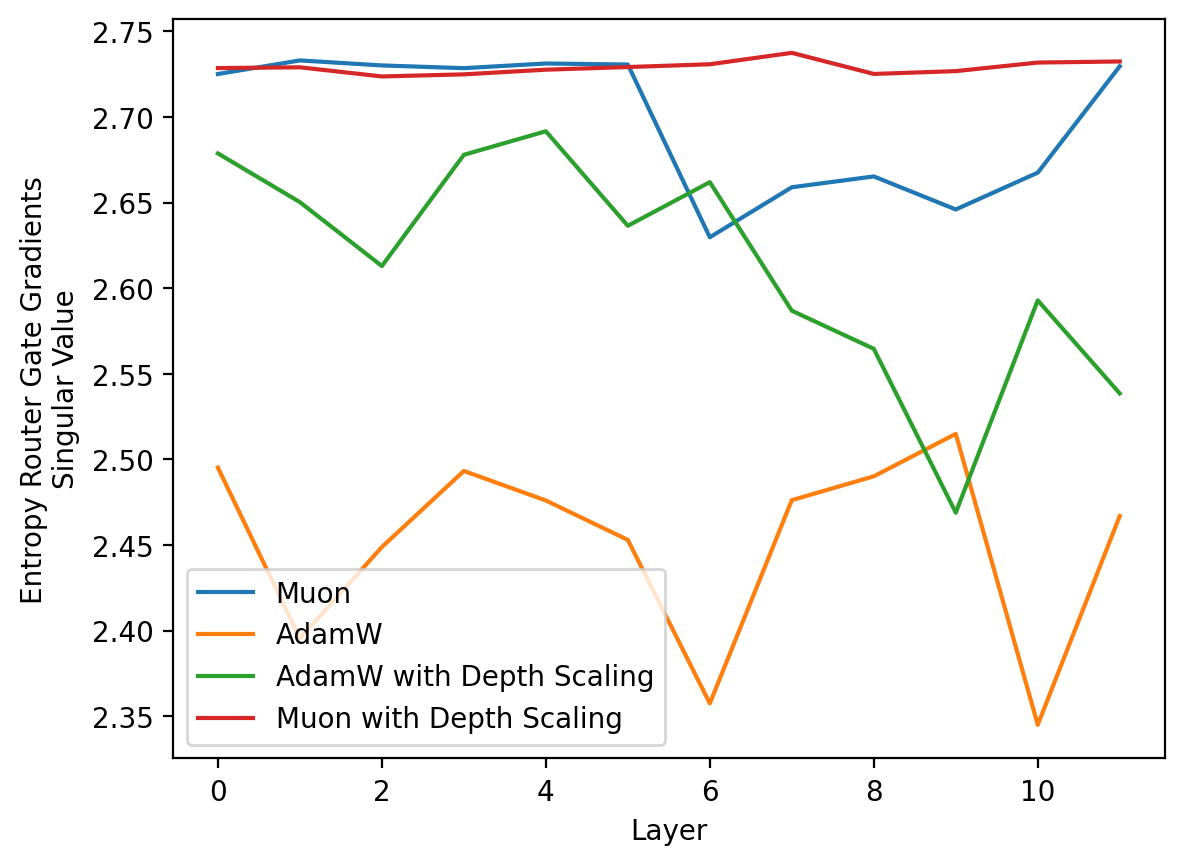

In [ ]:
plt.plot(router_gate_grad_stable_rank_muon, label='Muon')
plt.plot(router_gate_grad_stable_rank_adamw, label='AdamW')
plt.plot(router_gate_grad_stable_rank_adamw_with_depth_scaling, label='AdamW with Depth Scaling')
plt.plot(router_gate_grad_stable_rank_muon_with_depth_scaling, label='Muon with Depth Scaling')
plt.xlabel('Layer')
plt.ylabel('Entropy Router Gate Gradients\nSingular Value')
plt.legend()

In [6]:
def extract_monitor_results(R):
    all_avg_cos = [
        r.mean_off_diagonal_cosine
        for r in R.intra_sequence
    ]
    all_neighbour_layer_stats = [
        (r.mean_token_cosine, r.mean_rms_distance, r.mean_relative_rms_change)
        for r in R.neighbouring_layers
    ]
    all_router_stats = [
        r.entropy for r in R.router_usage_entropy
    ]
    return np.array(all_avg_cos), np.array(all_neighbour_layer_stats), np.array(all_router_stats)


def run_multiple_steps(model, optimizers, steps=50,
                        grad_accum=1, aux_loss_coef=0.0,
                        activate_router_freq=10,
                        return_router_monitor=False):
    # router_monitor = RouterImbalanceMonitor(model)
    data_iter = iter(dataset)
    all_losses = []
    hidden_states_metrics = []
    for step_id in range(steps):
        if step_id % activate_router_freq == 0:
            hidden_states_metrics.append(
                extract_monitor_results(hidden_state_cosine_similarities(
                    model=model,
                    dataset=iter(val_dataset),
                    batch_size=1,
                    max_batches=1,)
                ))
        model.compile()
        forward_time_start = time.time()
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.zero_grad(set_to_none=True)
        else:
            optimizers.zero_grad(set_to_none=True)
        step_loss = 0.0
        step_aux = 0.0
        step_tokens = 0
        step_router_monitor = []
        for _ in range(grad_accum):
            batch = next(data_iter)
            with torch.autocast(device_type="cuda", dtype=dtype):
                loss, metrics = compute_pretrain_loss(batch,
                aux_loss_coef=aux_loss_coef,
                return_router_logits=return_router_monitor)

            (loss / grad_accum).backward()
            step_loss += metrics["loss"]
            step_aux += metrics["aux_loss"]
            step_tokens += metrics["tokens"]
            step_router_monitor += metrics.get("expert_entropy_by_layer", [])
        foward_time = time.time() - forward_time_start
        backward_time_start = time.time()
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.step()
        else:
            optimizers.step()
        backward_time = time.time() - backward_time_start
        all_losses.append(
            {
            "loss": step_loss / grad_accum,
            "aux_loss": step_aux / grad_accum,
            "tokens": step_tokens,
            "forward_time": foward_time,
            "backward_time": backward_time,
            "router_monitor": step_router_monitor
        })
    return all_losses, hidden_states_metrics
    # return router_monitor

In [ ]:
data_iter = iter(dataset)
batch = next(data_iter)
batch = batch.to(device, non_blocking=True)
input_ids = batch.tokens.unsqueeze(0)
position_ids = batch.position_ids.unsqueeze(0)
doc_ids, seq_lens = cu_seqlens_to_packing_metadata(batch.cu_seqlens)

In [9]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
tokenizer.model_max_length = max_seq_len
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

# constant = 0.2
# alpha = 0.5
# residual_scale = constant / (model_config.num_layers ** alpha)
# model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()
print(f"model_params={model.num_parameters() / 1e6:.1f}M")
lr = 3e-4
optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_adamw, hidden_states_metrics_adamw_no_scaling = run_multiple_steps(
    model,
    optimizers,
    steps=200,
    activate_router_freq=50,
    return_router_monitor=True
)

model_params=558.7M


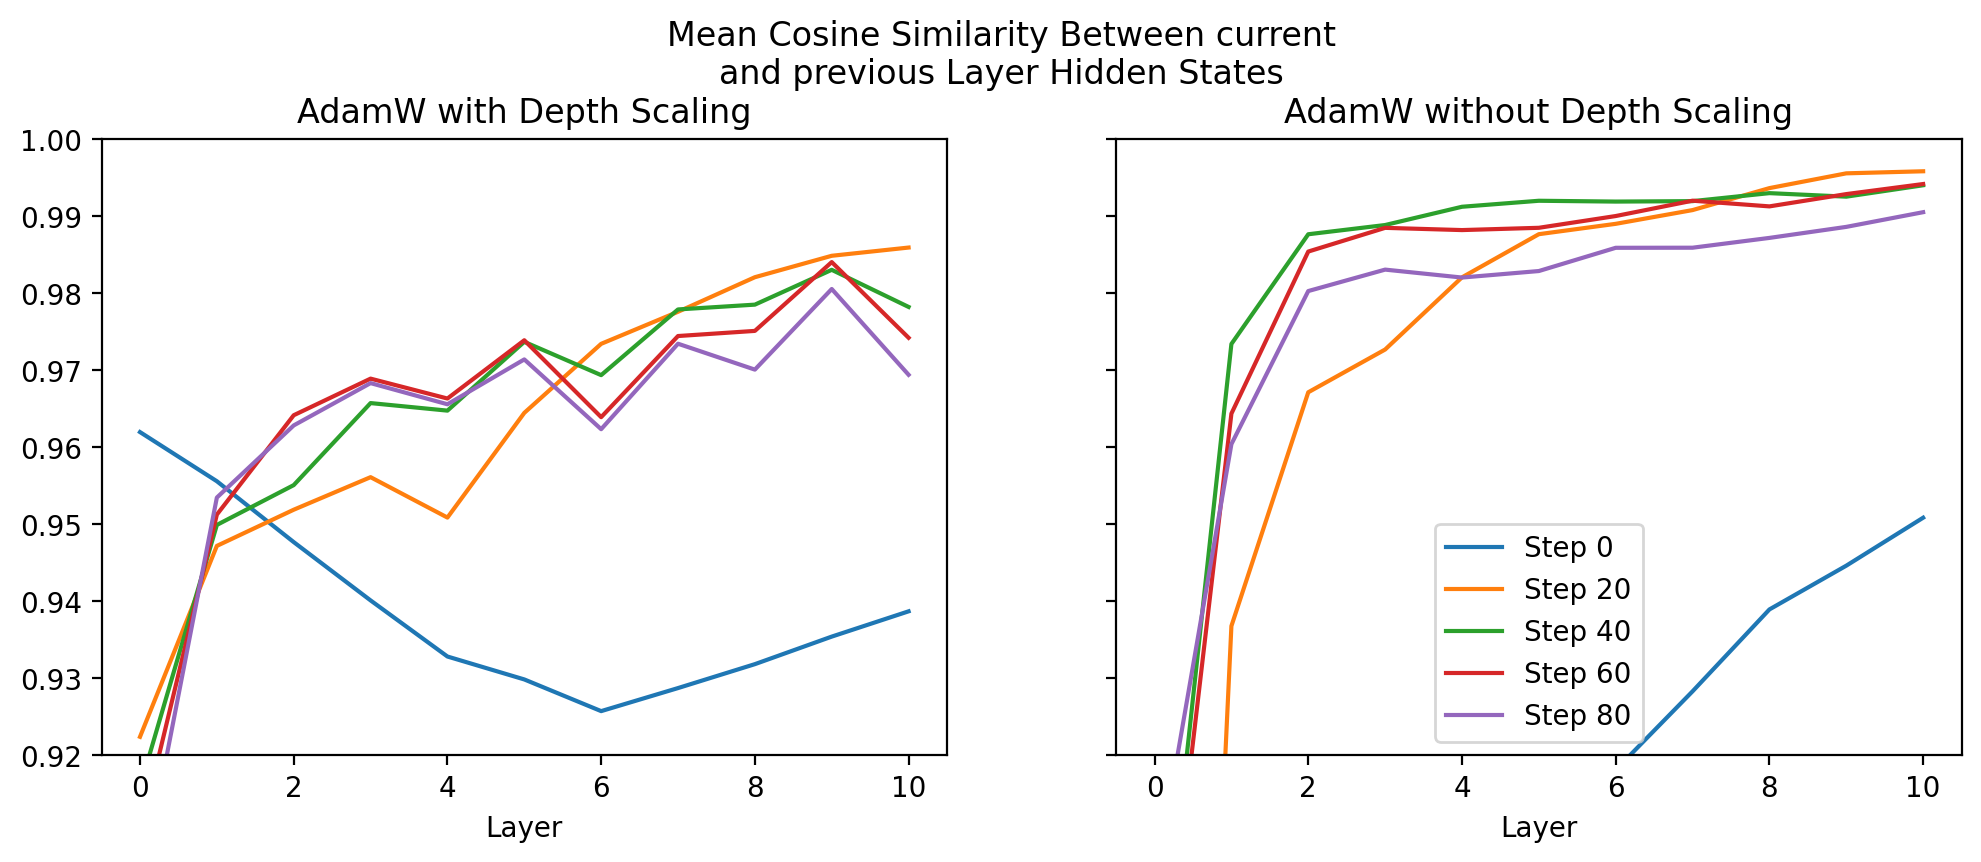

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i in range(10)[::2]:
    ax[0].plot(hidden_states_metrics_adamw_with_scaling[i][1][:, 0], label=f"Step {i}")

for i in range(10)[::2]:
    ax[1].plot(hidden_states_metrics_adamw_no_scaling[i][1][:, 0], label=f"Step {i * 10}")
ax[0].set_ylim(0.92, 1.0)
ax[0].set_title("AdamW with Depth Scaling")
ax[1].set_title("AdamW without Depth Scaling")
ax[0].set_xlabel("Layer")
ax[1].set_xlabel("Layer")
fig.suptitle("Mean Cosine Similarity Between current\nand previous Layer Hidden States", y=1.03)
# ax[0].legend()
ax[1].legend()

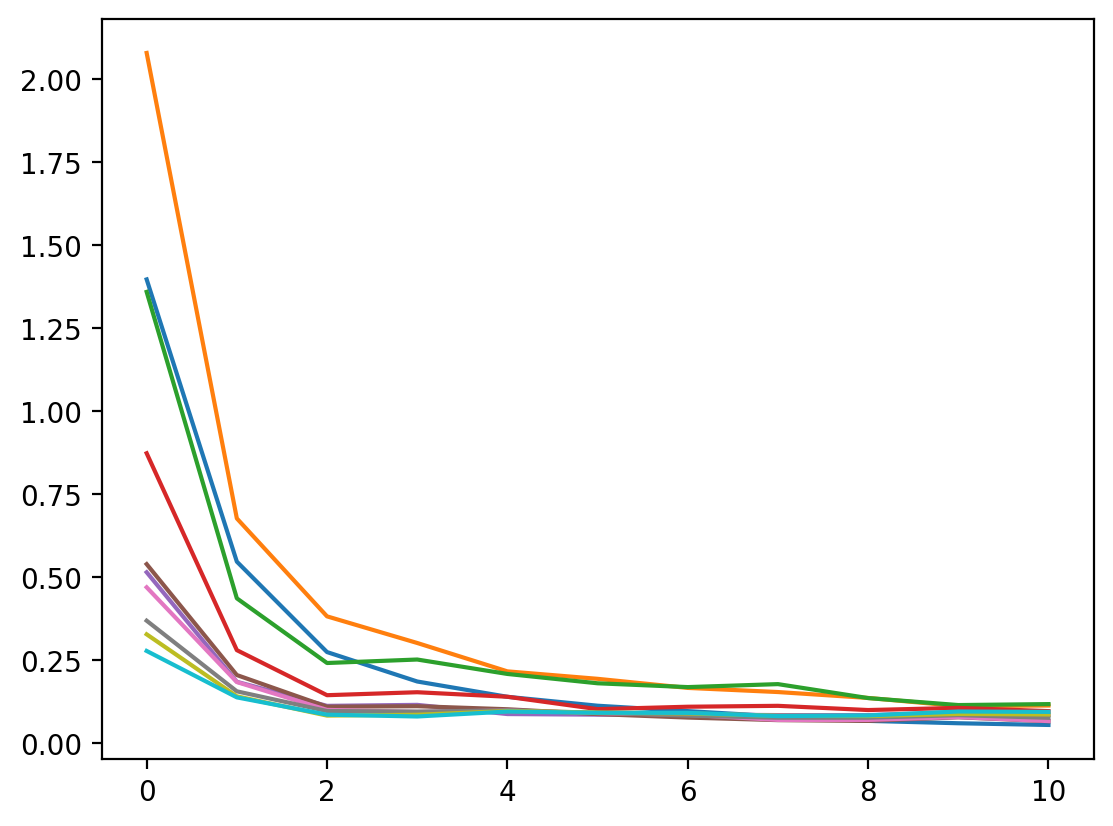

In [39]:
for i in range(10)[::]:
    plt.plot(hidden_states_metrics_adamw_no_scaling[i][1][:, 2])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

# constant = 0.2
# alpha = 0.5
# residual_scale = constant / (model_config.num_layers ** alpha)
# model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.compile()
model.train()
lr = 5e-4
optimizers = build_optimizer_muon(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_muon = run_multiple_steps(model, optimizers, steps=50, return_router_monitor=True)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

constant = 0.2
alpha = 0.5
residual_scale = constant / (model_config.num_layers ** alpha)
model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.compile()
model.train()
lr = 5e-4
optimizers = build_optimizer_muon(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_depth_scaled_muon = run_multiple_steps(model, optimizers, steps=50, return_router_monitor=True)

In [36]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

constant = 0.2
alpha = 0.5
residual_scale = constant / (model_config.num_layers ** alpha)
model_config.residual_scale = residual_scale

model = create_model(model_config).to(device=device, dtype=dtype)
model.compile()
model.train()
lr = 3e-4
optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_depth_scaled_adamw, hidden_states_metrics_adamw_with_scaling = run_multiple_steps(model, optimizers, steps=100, return_router_monitor=True)

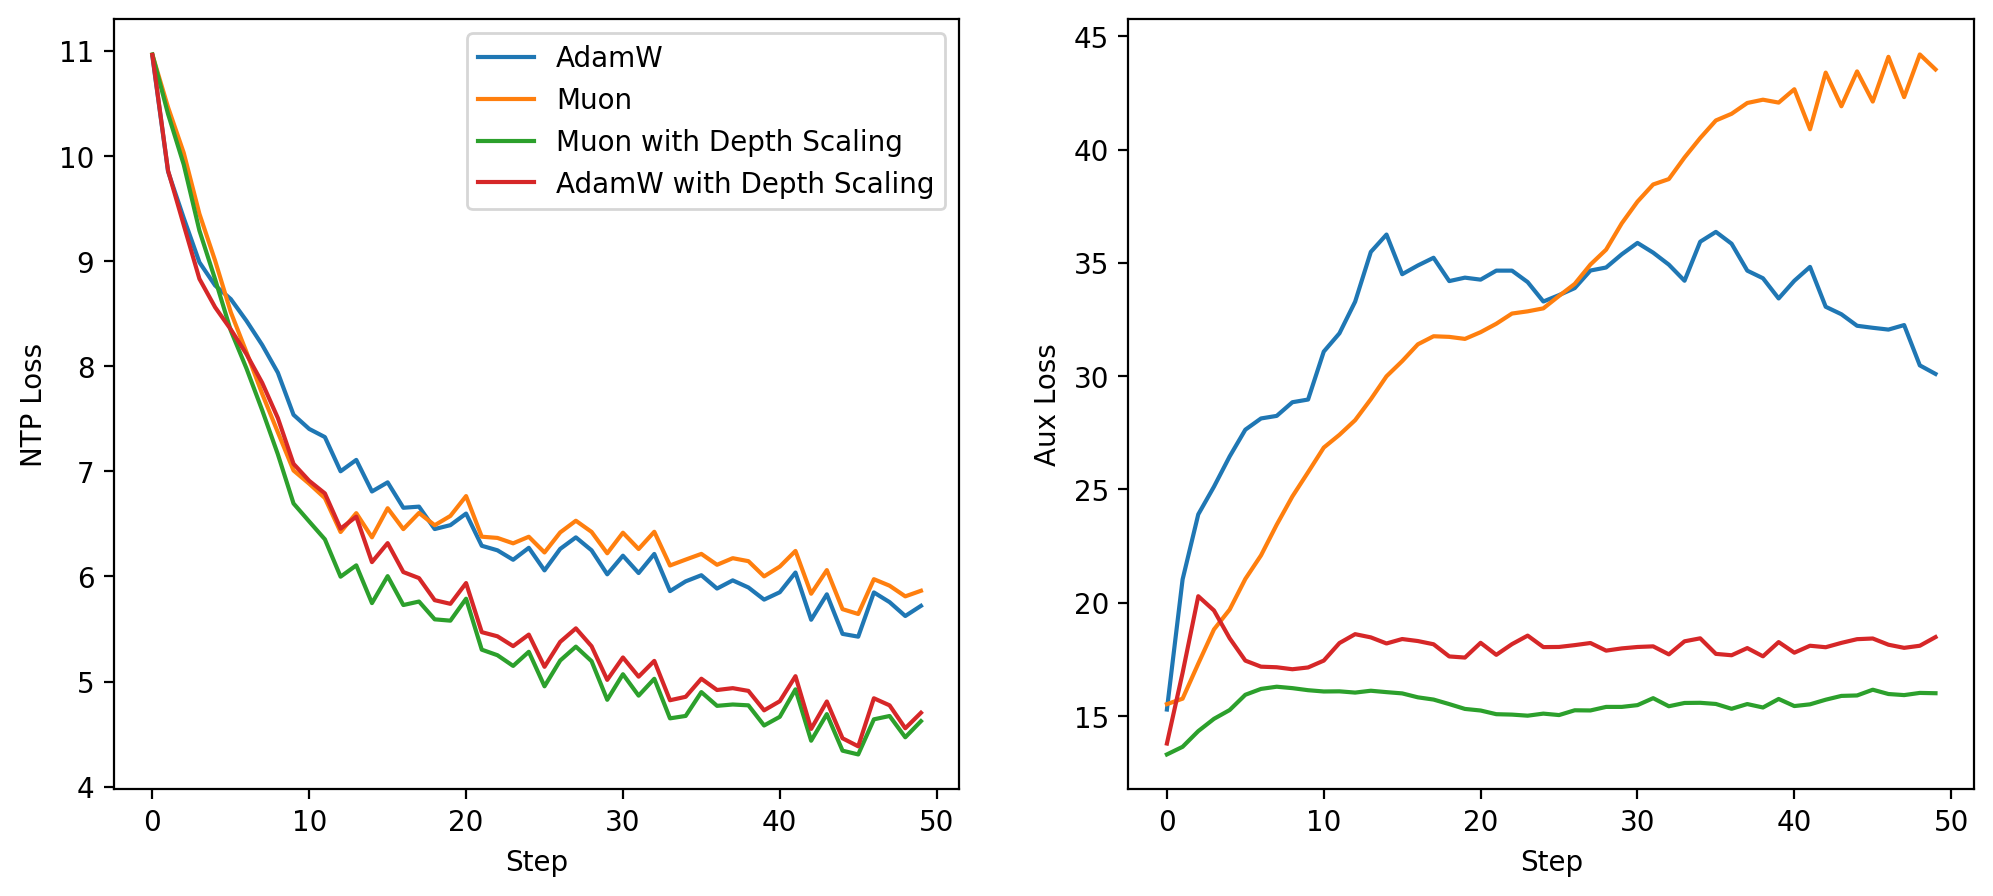

In [ ]:
log_dict = {
    'AdamW': log_adamw,
    'Muon': log_muon,
    'Muon with Depth Scaling': log_depth_scaled_muon,
    'AdamW with Depth Scaling': log_depth_scaled_adamw,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, log in log_dict.items():
    loss = list(map(itemgetter('loss'), log))
    aux_loss = list(map(itemgetter('aux_loss'), log))
    axes[0].plot(loss, label=name)
    axes[1].plot(aux_loss, label=f"{name} Backward")
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('NTP Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Aux Loss')
axes[0].legend()

Text(0, 0.5, 'Expert usage\nentropy')

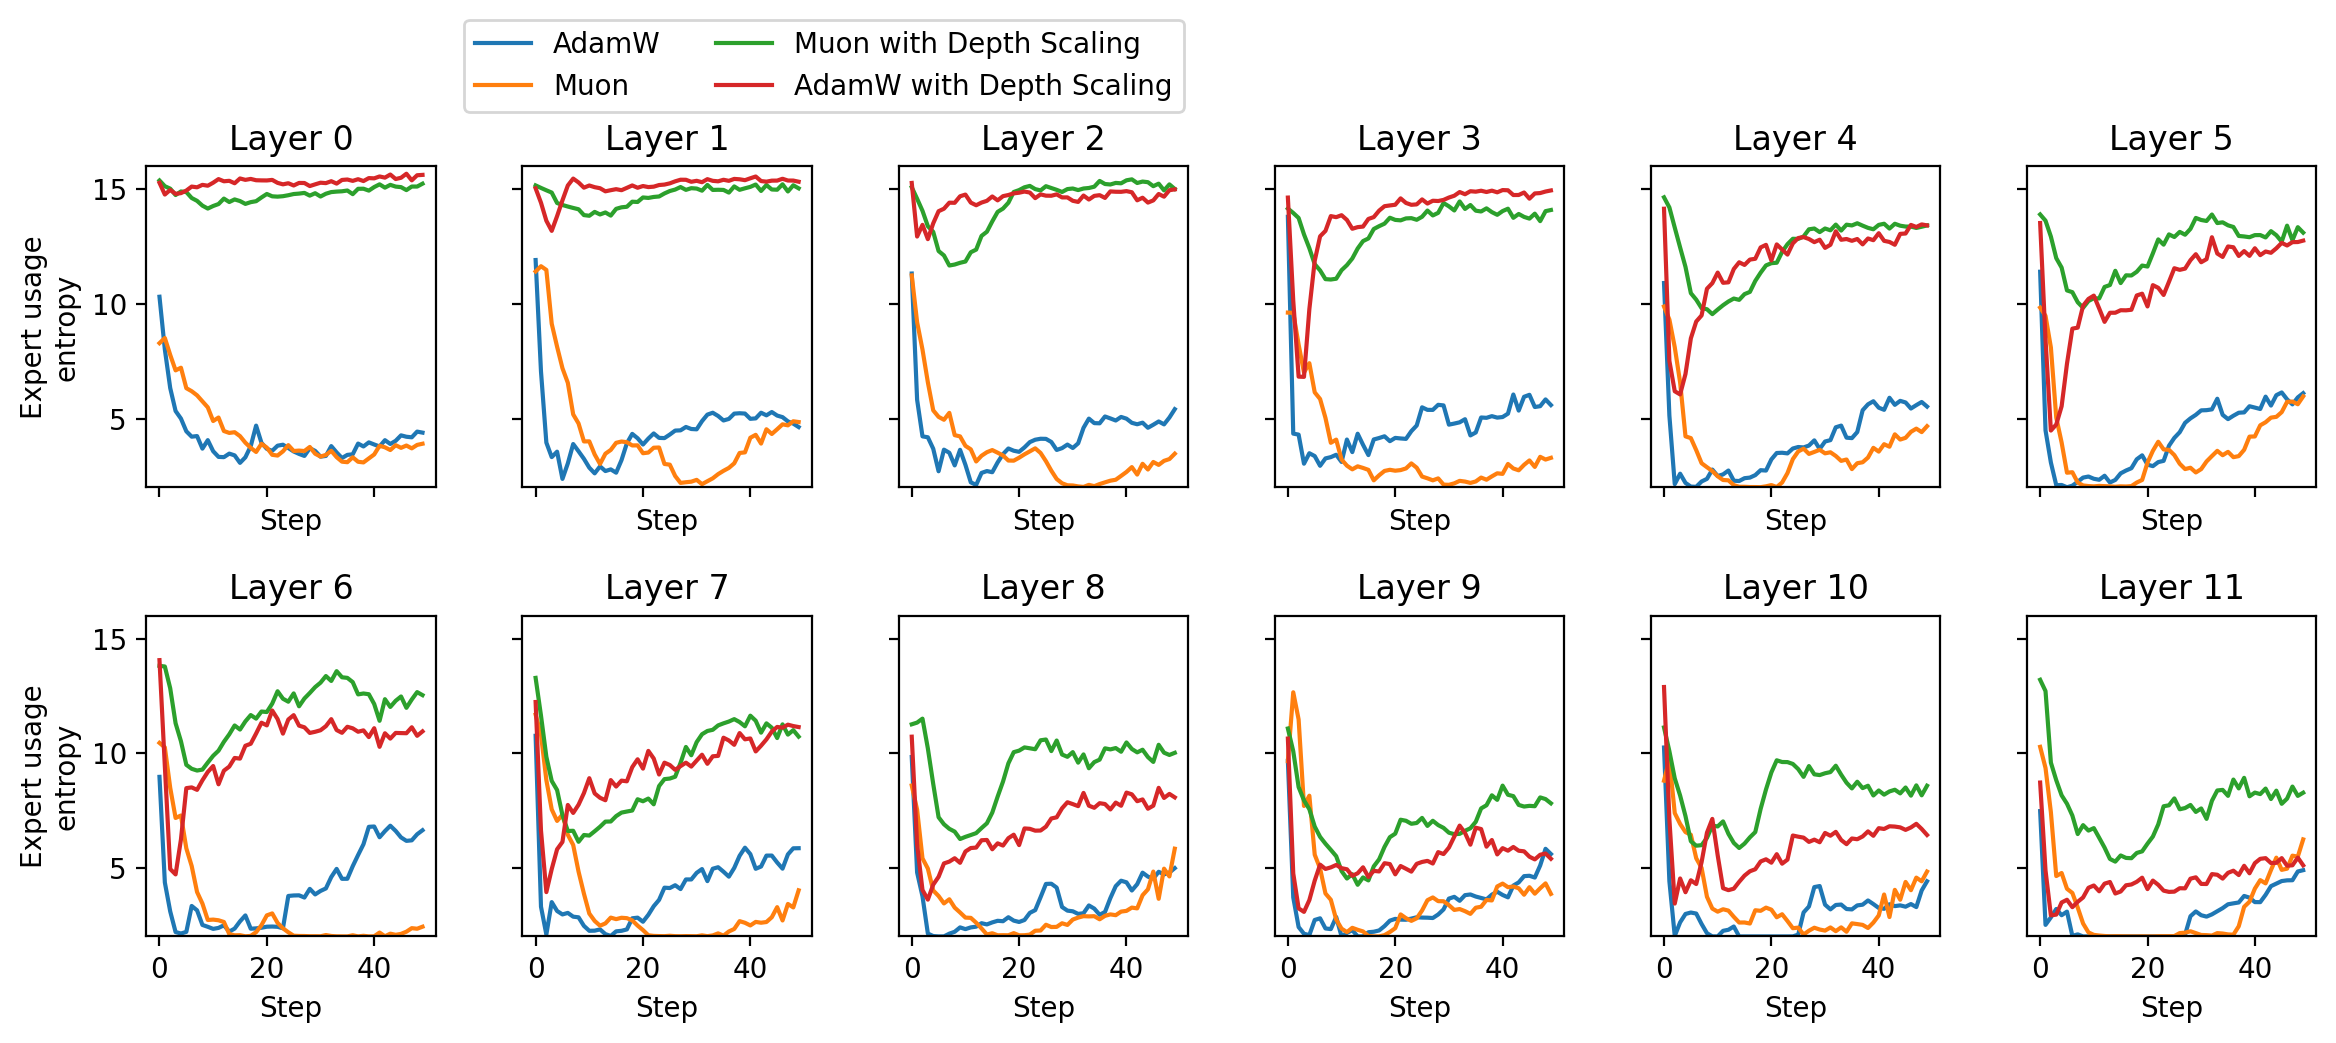

In [ ]:
log_dict = {
    'AdamW': log_adamw,
    'Muon': log_muon,
    'Muon with Depth Scaling': log_depth_scaled_muon,
    'AdamW with Depth Scaling': log_depth_scaled_adamw,
}

fig, axes = plt.subplots(2, 6, figsize=(14, 5), sharey='row', sharex='col')
fig.subplots_adjust(wspace=0.3, hspace=0.4)
for name, log in log_dict.items():
    loss = list(map(itemgetter('loss'), log))
    aux_loss = list(map(itemgetter('router_monitor'), log))
    for i in range(len(aux_loss[0])):
        layer_i_aux_loss = [x[i] for x in aux_loss]
        axes[i // 6, i % 6].plot(2 ** np.array(layer_i_aux_loss), label=name)
        axes[i // 6, i % 6].set_xlabel('Step')
        axes[i // 6, i % 6].set_title(f'Layer {i}')
        # axes[i // 6, i % 6].set_ylim(0, math.log2(model_config.num_experts))
        axes[i // 6, i % 6].set_ylim(2, 16)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1.5), loc='upper left', ncols=2)
axes[0, 0].set_ylabel('Expert usage\nentropy')
axes[1, 0].set_ylabel('Expert usage\nentropy')

In [ ]:
total_tokens = 0
window_loss = 0.0
window_aux = 0.0
window_tokens = 0
window_steps = 0
window_start = time.time()
all_metrics_no_depth_scaling = []
router_monitor = RouterImbalanceMonitor(model)
try:
    for step in range(1, max_steps + 1):
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.zero_grad(set_to_none=True)
        else:
            optimizers.zero_grad(set_to_none=True)

        step_loss = 0.0
        step_aux = 0.0
        step_tokens = 0
        for _ in range(grad_accum):
            batch = next(data_iter)
            with torch.autocast(device_type="cuda", dtype=dtype):
                loss, metrics = compute_pretrain_loss(batch)

            (loss / grad_accum).backward()
            step_loss += metrics["loss"]
            step_aux += metrics["aux_loss"]
            step_tokens += metrics["tokens"]

        if max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.step()
        else:
            optimizers.step()

        total_tokens += step_tokens
        window_tokens += step_tokens
        window_loss += step_loss / grad_accum
        window_aux += step_aux / grad_accum
        window_steps += 1
        if step % log_every == 0 or step == 1:
            torch.cuda.synchronize()
            elapsed = max(time.time() - window_start, 1e-6)
            denom = max(window_steps, 1)
            router_stats = router_monitor.summarize()
            print(
                f"step={step:04d} "
                f"loss={window_loss / denom:.4f} "
                f"aux={window_aux / denom:.4f} "
                f"router_imb={router_stats['router_usage_imbalance']:.4f} "
                f"router_imp_imb={router_stats['router_importance_imbalance']:.4f} "
                f"router_max={router_stats['router_max_load_ratio']:.2f}x "
                f"router_cv={router_stats['router_load_cv']:.3f} "
                f"worst_layer={router_stats['router_worst_layer']} "
                f"router_gate_gn={router_stats['router_gate_grad_norm']:.2e} "
                f"router_gate_rank={router_stats['router_gate_grad_rank']:.1f} "
                f"router_gate_sr={router_stats['router_gate_grad_stable_rank']:.2f} "
                f"router_logits_gn={router_stats['router_logits_grad_norm']:.2e} "
                f"router_logits_rank={router_stats['router_logits_grad_rank']:.1f} "
                f"router_logits_sr={router_stats['router_logits_grad_stable_rank']:.2f} "
                f"tokens={total_tokens:,} "
                f"tokens/s={window_tokens / elapsed:,.0f}"
            )
            window_loss = 0.0
            window_aux = 0.0
            window_tokens = 0
            window_steps = 0
            router_monitor.reset()
            all_metrics_no_depth_scaling.append(
                {
                    "step": step,
                    "loss": step_loss / grad_accum,
                    "aux_loss": step_aux / grad_accum,
                    **router_stats,
                }
            )
            window_start = time.time()
finally:
    dataset.stop()

W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0] Graph break from `Tensor.item()`, consider setting:
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0] or:
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0] to include these operations in the captured graph.
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0] 
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0] Graph break: from user code at:
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [0/0]   File "/weka/scratch/enalisn1/xwang/nanomoe/src/nanomoe/model/attention.py", line 294, in forward
W0422 12:34:58.417000 31058 torch/_dynamo/variables/tensor.py:1079] [

step=0001 loss=12.0372 aux=0.1690 router_imb=0.3009 router_imp_imb=0.0370 router_max=4.00x router_cv=1.090 worst_layer=9 tokens=12,619 tokens/s=532
step=0005 loss=11.9185 aux=0.1753 router_imb=0.3262 router_imp_imb=0.0421 router_max=4.00x router_cv=1.145 worst_layer=6 tokens=67,582 tokens/s=22,541
step=0010 loss=11.6872 aux=0.1705 router_imb=0.3001 router_imp_imb=0.0382 router_max=4.00x router_cv=1.093 worst_layer=5 tokens=142,263 tokens/s=23,047
step=0015 loss=11.3436 aux=0.1851 router_imb=0.3730 router_imp_imb=0.0502 router_max=4.00x router_cv=1.239 worst_layer=5 tokens=205,282 tokens/s=21,821
step=0020 loss=10.8456 aux=0.1933 router_imb=0.4279 router_imp_imb=0.0564 router_max=4.00x router_cv=1.349 worst_layer=9 tokens=271,225 tokens/s=21,629
step=0025 loss=10.4518 aux=0.1964 router_imb=0.4399 router_imp_imb=0.0587 router_max=4.00x router_cv=1.361 worst_layer=9 tokens=332,808 tokens/s=21,850
step=0030 loss=10.0767 aux=0.1923 router_imb=0.4207 router_imp_imb=0.0545 router_max=4.00x ro

In [ ]:
total_tokens = 0
window_loss = 0.0
window_aux = 0.0
window_tokens = 0
window_steps = 0
window_start = time.time()
all_metrics = []
router_monitor = RouterImbalanceMonitor(model)
try:
    for step in range(1, max_steps + 1):
        optimizers.zero_grad(set_to_none=True)

        step_loss = 0.0
        step_aux = 0.0
        step_tokens = 0
        for _ in range(grad_accum):
            batch = next(data_iter)
            with torch.autocast(device_type="cuda", dtype=dtype):
                loss, metrics = compute_pretrain_loss(batch)

            (loss / grad_accum).backward()
            step_loss += metrics["loss"]
            step_aux += metrics["aux_loss"]
            step_tokens += metrics["tokens"]

        if max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizers.step()

        total_tokens += step_tokens
        window_tokens += step_tokens
        window_loss += step_loss / grad_accum
        window_aux += step_aux / grad_accum
        window_steps += 1

        if step % log_every == 0 or step == 1:
            torch.cuda.synchronize()
            elapsed = max(time.time() - window_start, 1e-6)
            denom = max(window_steps, 1)
            router_stats = router_monitor.summarize()
            print(
                f"step={step:04d} "
                f"loss={window_loss / denom:.4f} "
                f"aux={window_aux / denom:.4f} "
                f"router_imb={router_stats['router_usage_imbalance']:.4f} "
                f"router_imp_imb={router_stats['router_importance_imbalance']:.4f} "
                f"router_max={router_stats['router_max_load_ratio']:.2f}x "
                f"router_cv={router_stats['router_load_cv']:.3f} "
                f"worst_layer={router_stats['router_worst_layer']} "
                f"router_gate_gn={router_stats['router_gate_grad_norm']:.2e} "
                f"router_gate_rank={router_stats['router_gate_grad_rank']:.1f} "
                f"router_gate_sr={router_stats['router_gate_grad_stable_rank']:.2f} "
                f"router_logits_gn={router_stats['router_logits_grad_norm']:.2e} "
                f"router_logits_rank={router_stats['router_logits_grad_rank']:.1f} "
                f"router_logits_sr={router_stats['router_logits_grad_stable_rank']:.2f} "
                f"tokens={total_tokens:,} "
                f"tokens/s={window_tokens / elapsed:,.0f}"
            )
            window_loss = 0.0
            window_aux = 0.0
            window_tokens = 0
            window_steps = 0
            router_monitor.reset()
            all_metrics.append(
                {
                    "step": step,
                    "loss": step_loss / grad_accum,
                    "aux_loss": step_aux / grad_accum,
                    **router_stats,
                }
            )
            window_start = time.time()
finally:
    dataset.stop()

step=0001 loss=12.0372 aux=0.1690 router_imb=0.3009 router_imp_imb=0.0370 router_max=4.00x router_cv=1.090 worst_layer=9 tokens=12,619 tokens/s=751
step=0005 loss=11.0866 aux=0.2002 router_imb=0.4703 router_imp_imb=0.0617 router_max=4.00x router_cv=1.409 worst_layer=9 tokens=67,582 tokens/s=24,896
step=0010 loss=10.4177 aux=0.2111 router_imb=0.5501 router_imp_imb=0.0708 router_max=4.00x router_cv=1.550 worst_layer=9 tokens=142,263 tokens/s=25,864
step=0015 loss=10.0504 aux=0.2192 router_imb=0.5832 router_imp_imb=0.0778 router_max=4.00x router_cv=1.604 worst_layer=9 tokens=205,282 tokens/s=23,153
step=0020 loss=9.3695 aux=0.2266 router_imb=0.6094 router_imp_imb=0.0869 router_max=4.00x router_cv=1.646 worst_layer=8 tokens=271,225 tokens/s=24,469
step=0025 loss=8.8774 aux=0.2273 router_imb=0.6095 router_imp_imb=0.0899 router_max=4.00x router_cv=1.646 worst_layer=7 tokens=332,808 tokens/s=23,485
step=0030 loss=8.5316 aux=0.2291 router_imb=0.5923 router_imp_imb=0.0930 router_max=4.00x route

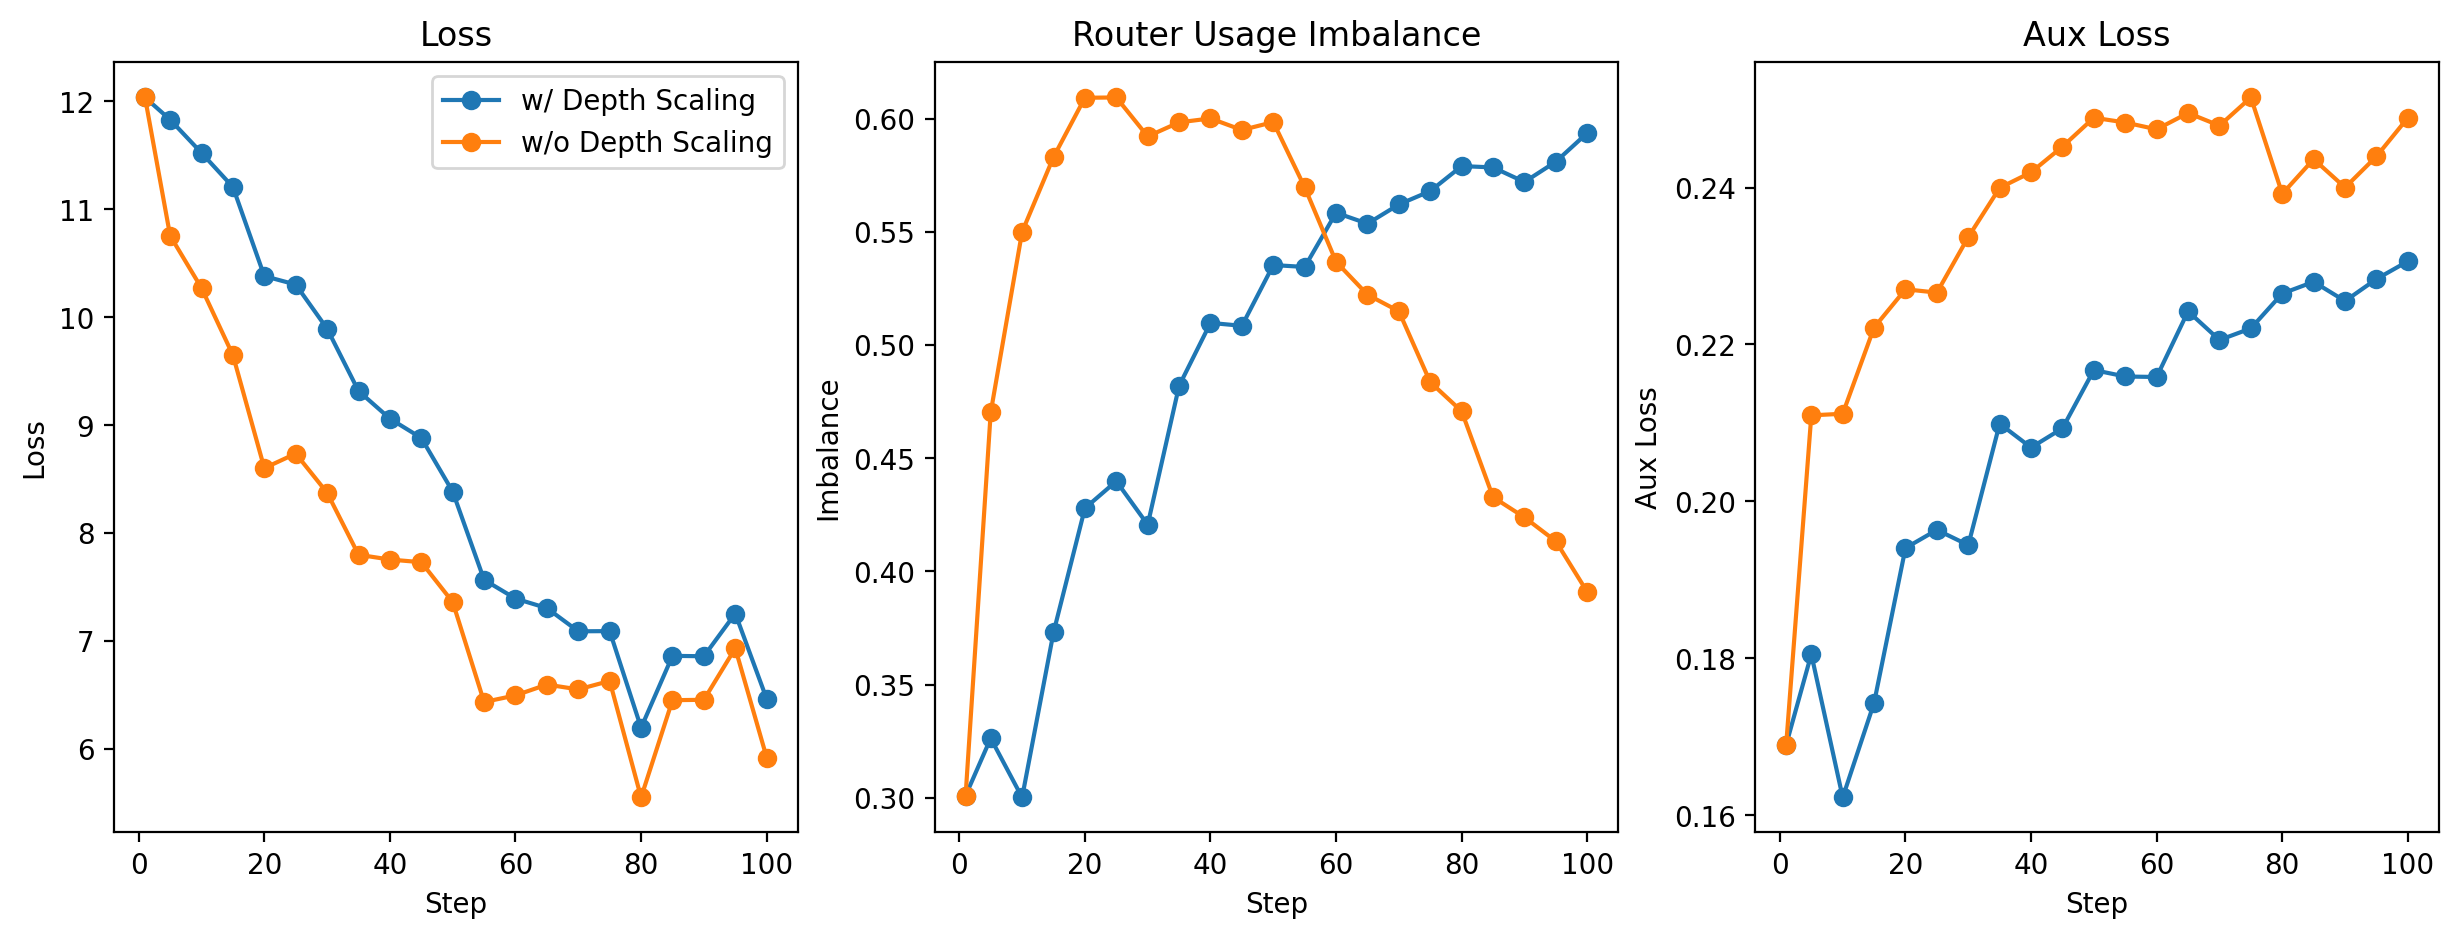

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for metrics, title in [(all_metrics_no_depth_scaling, "w/ Depth Scaling"), (all_metrics, "w/o Depth Scaling")]:
    steps = [m["step"] for m in metrics]
    aux_losses = [m["aux_loss"] for m in metrics]
    axes[2].plot(steps, aux_losses, marker="o")
    axes[2].set_title(f"Aux Loss")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Aux Loss")
    losses = [m["loss"] for m in metrics]
    imbalances = [m["router_usage_imbalance"] for m in metrics]

    axes[0].plot(steps, losses, marker="o", label=title)
    axes[0].set_title(f"Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")

    axes[1].plot(steps, imbalances, marker="o")
    axes[1].set_title(f"Router Usage Imbalance")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Imbalance")
axes[0].legend()
# all_metrics

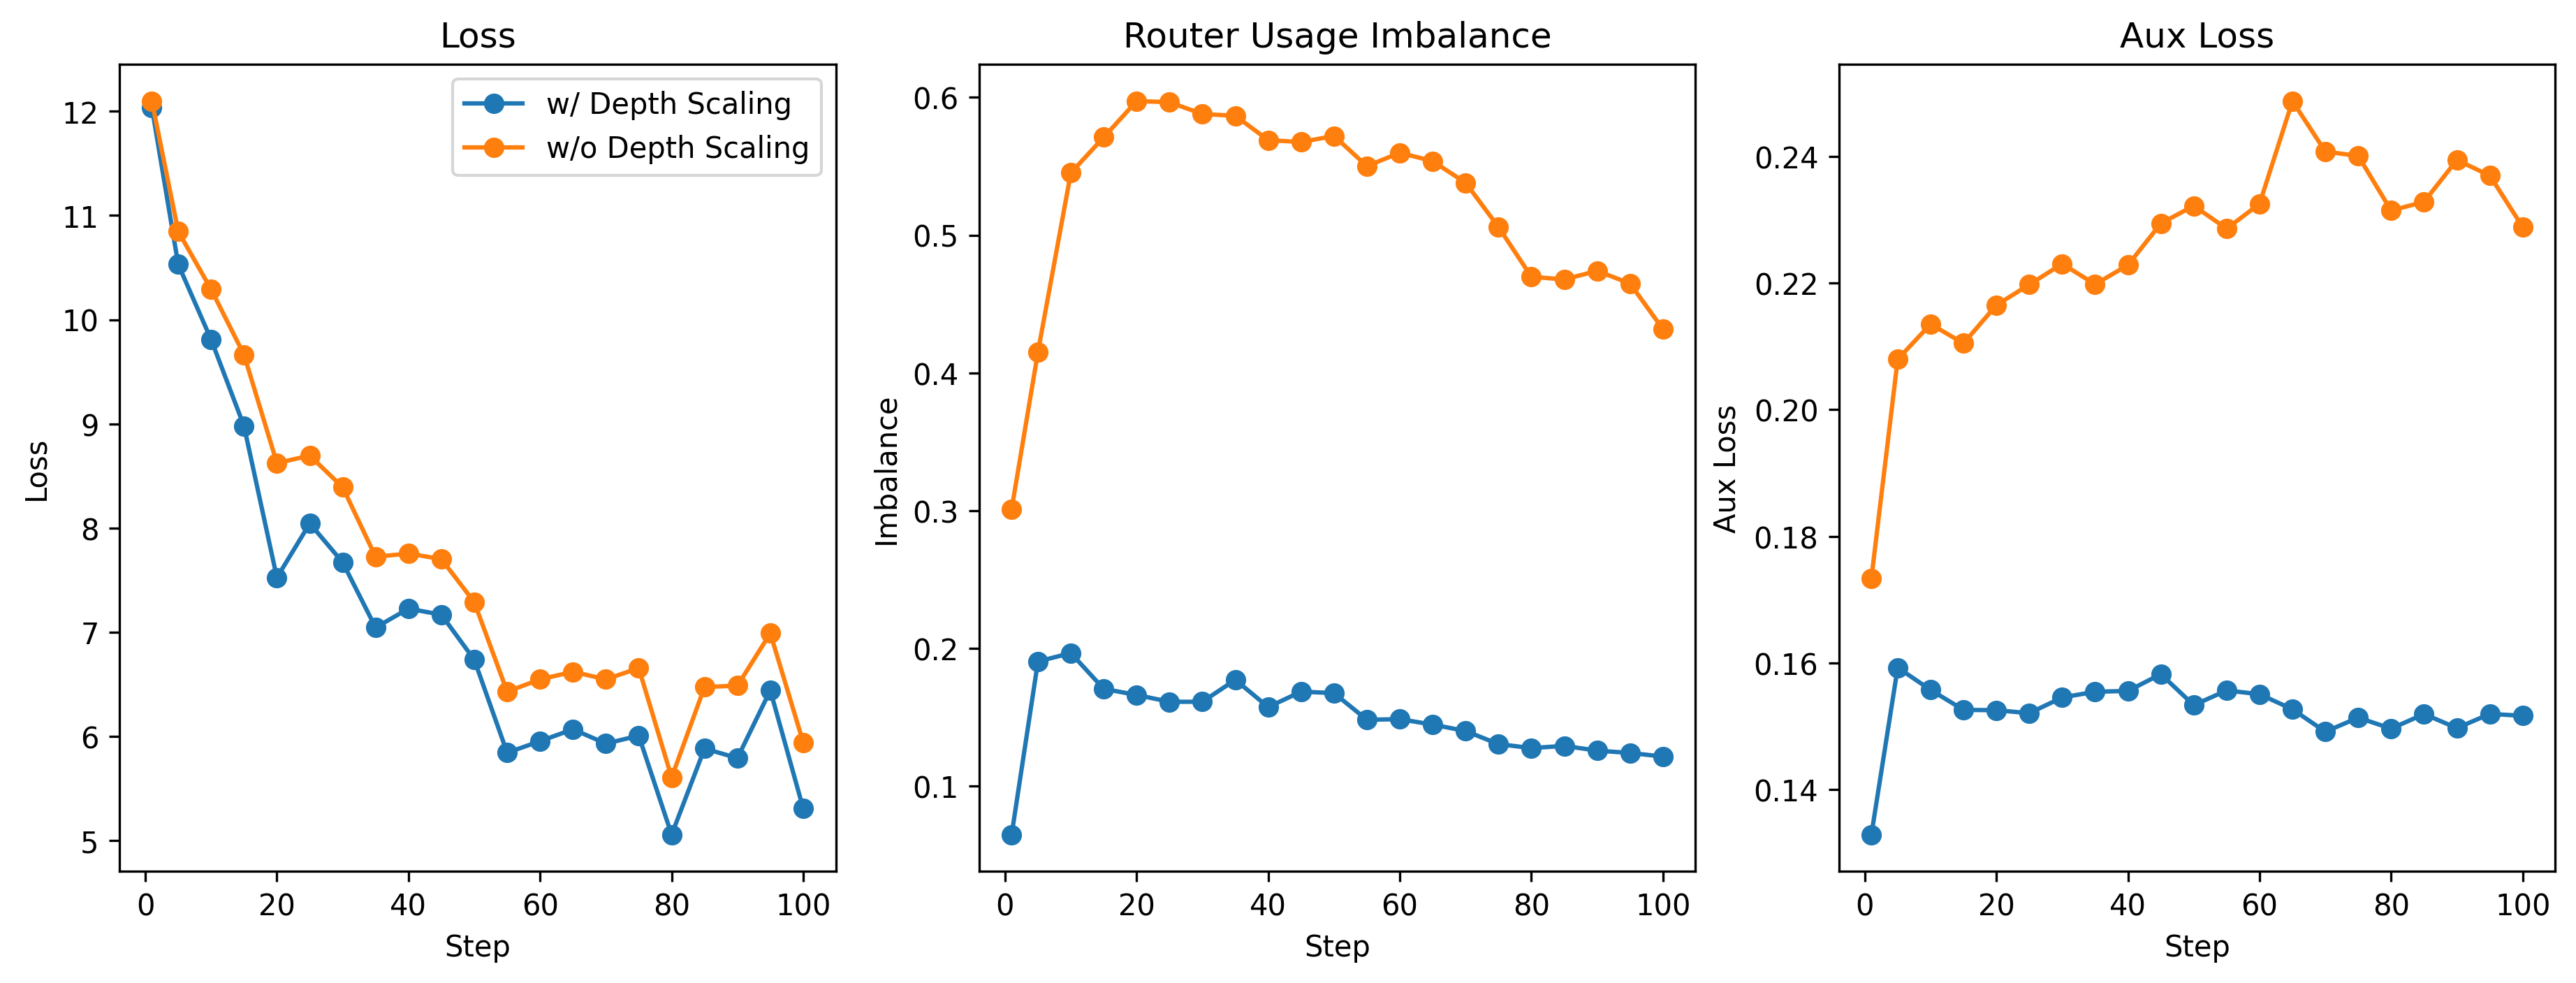

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for metrics, title in [(all_metrics_no_depth_scaling, "w/ Depth Scaling"), (all_metrics, "w/o Depth Scaling")]:
    steps = [m["step"] for m in metrics]
    aux_losses = [m["aux_loss"] for m in metrics]
    axes[2].plot(steps, aux_losses, marker="o")
    axes[2].set_title(f"Aux Loss")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Aux Loss")
    losses = [m["loss"] for m in metrics]
    imbalances = [m["router_usage_imbalance"] for m in metrics]

    axes[0].plot(steps, losses, marker="o", label=title)
    axes[0].set_title(f"Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")

    axes[1].plot(steps, imbalances, marker="o")
    axes[1].set_title(f"Router Usage Imbalance")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Imbalance")
axes[0].legend()
# all_metrics

In [ ]:
# Optional: save a checkpoint after the notebook run.
# checkpoint_dir = Path("../checkpoints/notebook_nemomath_small")
# checkpoint_dir.mkdir(parents=True, exist_ok=True)
# torch.save(
#     {
#         "model": model.state_dict(),
#         "optimizer": optimizer.state_dict(),
#         "model_config": model_config.to_dict(),
#         "tokens_seen": total_tokens,
#     },
#     checkpoint_dir / "last.pt",
# )